 # Столбцы

 order_id – номер заявки<br>

 created_at - дата создания заявки<br>

 put_at - дата выдачи<br>

 closed_at - дата закрытия<br>

 issued_sum - сумма выдачи<br>

 plan_at - дата планового платежа<br>

 plan_sum_total - сумма планового платежа (накопленным итогом)<br>

 paid_at - дата фактического платежа<br>

 paid_sum - сумма фактического платежа<br>

 # Определения



 **Просрочка**— это нарушение должником сроков и/или объёмов исполнения обязательств, предусмотренных договором (графиком платежей).



 Уточним определение, применительно к данному исследованию



 **Просрочка по плажету**(далее Просрочка)<br>

 Просрочкой по платежу будем называть *недостаток средств* по счету заявки после даты планового платежа.



 **Недостаток средств**<br>

 В день плановой даты накопленный итог больше, чем сумма всех платежей. То есть сумма всех платежей не соответствует предъявленным обязательствам на дату.

 # Уточнения

 * Условия расчета суммы планового платежа не предоставлены, поэтому будем считать, что если заявка закрыта до следующей плановой даты платежом меньше планового, то обязательства по ней считаются исполненными в полной мере. Иначе говоря, для закрытых до планового срока заявок проценты расчитаны корректно и выплачены в полной мере.



 * Столбцы с денежными единицами имеют тип данных float, что может вести к ошибкам при вычислениях(знаменитое 0.1 + 0.2 != 0.3). Типы данных библиотеки numpy не предоставляют подходящих вариантов для выражения денежных единиц. Есть два способа решения этой проблемы:

     1. Считать все числа меньше 0.01 за 0

     2. Округлить все числа до двух знаков после запятой, умножить на 100 и перевести в целочиленный тип. В таком случае все незначительные числа(около e-13) будут выражены как 1 или 2. Погрешность составит менее 10 копеек.



     Задача не уточняет допустимую погрешность в денежных суммах, поэтому во избежание лишних допущений выбран первый способ. Для второго просто представлен код конвертации

 # Обработка таблиц и данных

 ## Библиотеки

In [178]:
%matplotlib inline
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import hmean

In [179]:
plt.rcParams['figure.figsize'] = (8, 4)
sns.set_style('white')

 ## Обзор таблиц

In [180]:
data_dir = Path.cwd() / 'task_2_data'
dfs = {
    str(data_file.stem): pd.read_csv(data_file)
    for data_file in data_dir.iterdir()
}

In [181]:
for name in dfs:
    print('\n' + '*' * 10 + name.upper() + '*' * 10)
    print(dfs[name].head())
    print()
    print(dfs[name].info())


**********ORDERS**********
    order_id               created_at                   put_at  \
0  400001732  2022-06-02 00:00:23.997  2022-06-02 20:18:00.180   
1  400005838  2022-06-02 00:10:22.997  2022-06-02 15:41:33.267   
2  400007915  2022-06-02 00:18:04.000  2022-06-05 19:17:38.547   
3  400008952  2022-06-02 00:22:07.000  2022-06-03 14:25:18.033   
4  400009027  2022-06-02 00:25:39.000  2022-06-02 00:40:40.320   

                 closed_at  issued_sum  
0  2022-10-17 11:52:22.190     13600.0  
1  2022-06-02 17:38:43.917     20000.0  
2  2022-06-21 21:55:51.877      5820.0  
3  2022-07-12 10:47:46.307      9000.0  
4  2022-06-22 14:15:07.423      5000.0  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55748 entries, 0 to 55747
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    55748 non-null  int64  
 1   created_at  55748 non-null  object 
 2   put_at      55748 non-null  object 
 3   closed_at 

 В таблице orders лишь уникальные order_id

In [182]:
dfs['orders']['order_id'].nunique() == dfs['orders'].shape[0]

True

 Для полей с временем установим тип данных datetime

In [183]:
orders = dfs['orders']
payments = dfs['payments']
plan = dfs['plan']
orders[['created_at', 'put_at', 'closed_at']] = orders[
    ['created_at', 'put_at', 'closed_at']
].apply(pd.to_datetime)
payments[['paid_at']] = payments[['paid_at']].apply(pd.to_datetime)
plan[['plan_at']] = plan[['plan_at']].apply(pd.to_datetime)

 Отсечем заявки выданные после релевантной даты (2022-08-12)

In [184]:
relevancy_date = pd.Timestamp('2022-08-12')
orders = (
    orders
    .loc[lambda x: x['put_at'] <= relevancy_date]
)

 Для полей с денежными значениями избавимся от ошибок плавающей точки, следующим образом:

 * округлим до 2го числа после точки

 * умножим на 100

 * переведем в целочисленный тип

In [185]:
# def to_money_type(x):
#     return round(x, 2) * 100

# orders[['issued_sum']] = orders[['issued_sum']].apply(to_money_type).astype(int)

 ## Примеры данных

In [186]:
# Закрыт заранее одним платежом
order_id = 400005838
# order_id = 400014289

# Закрыт полностью досрочно
# order_id = 400001732
# order_id = 400007915

# Ошибка плавающей точки
# order_id = 400564695

# Много просрочек
# order_id = 400039450

# Источники резкого скачка
# order_id = 414262167
# order_id = 413853839
# order_id = 414201755
# order_id = 413911250
# order_id = 414305554
# order_id = 414288881
# order_id = 429430737

display(orders[orders['order_id'] == order_id])
display(plan[plan['order_id'] == order_id])
display(payments[payments['order_id'] == order_id])

,order_id,created_at,put_at,closed_at,issued_sum
1,400005838,2022-06-02 00:10:22.997,2022-06-02 15:41:33.267,2022-06-02 17:38:43.917,20000.0


,order_id,plan_at,plan_sum_total
7,400005838,2022-06-17,23000.0


,order_id,paid_at,paid_sum
126,400005838,2022-06-02 17:38:43.917,20200.0


 ## Исправление ошибок в данных

 В ходе исследования в данных были найдены неточности в данных, выраженные несоответствием порядков значений выданной и запланированной сумм. Несоответсвие имеет закономерный характер и характеризуется 100-кратным различием. Подобное может быть вызвано намеренным изменением данных с целью отметки их источника, либо ошибками при выгрузке данных денежных значений из базы.

In [187]:
invalid_idx = (
    plan
    .merge(orders, on='order_id')
    .loc[lambda x: (x.plan_sum_total / x.issued_sum) > 10]
    .index
)

plan.loc[invalid_idx, ['plan_sum_total']] = (
    plan.loc[invalid_idx, ['plan_sum_total']] / 100
)


 # Анализ

 ## Анализ таблицы orders

Text(0.5, 0.98, 'Динамика новых выданных заявок')

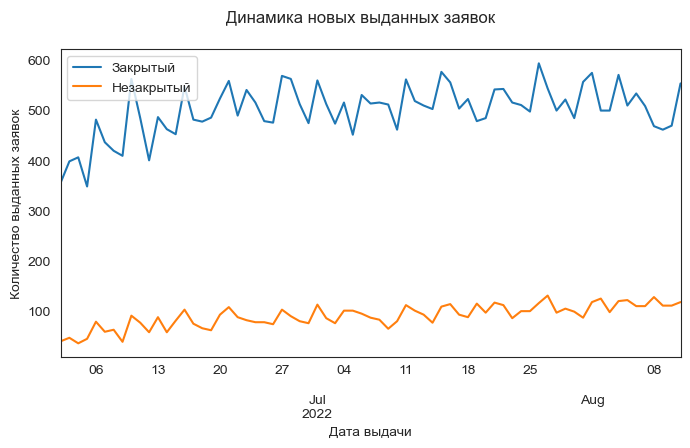

In [188]:
rus_names = {True: 'Закрытый', False: 'Незакрытый'}
data = (
    orders
    .assign(
        is_closed=lambda x: ~x['closed_at'].isna(),
        put_at_norm=lambda x: x['put_at'].dt.normalize(),
    )
    .groupby([pd.Grouper(key='put_at_norm', freq='D'), 'is_closed'])
    .agg({'order_id': 'nunique'})
    .reset_index()
    .pivot(index='put_at_norm', columns='is_closed', values='order_id')
    .rename(columns=rus_names)
)
ax = data.plot(y=['Закрытый', 'Незакрытый'])

plt.ylabel('Количество выданных заявок')
plt.xlabel('Дата выдачи')
plt.legend(loc='upper left')
plt.suptitle('Динамика новых выданных заявок')

Text(0, 0.5, '')

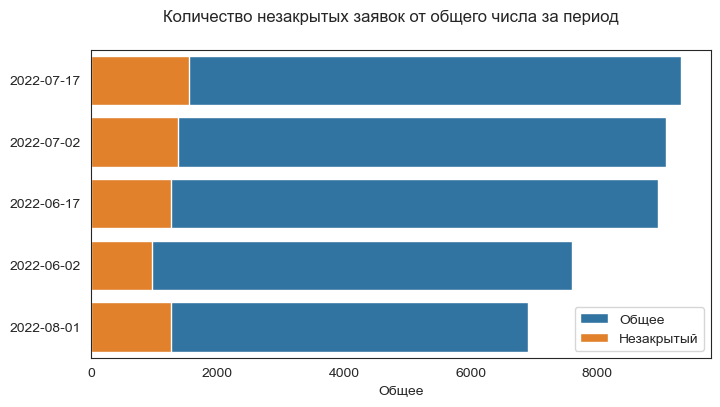

In [189]:
rus_names = {True: 'Закрытый', False: 'Незакрытый', 'total': 'Общее'}
group_frequency = '15D'
data = (
    orders
    .assign(
        is_closed=lambda x: ~x['closed_at'].isna(),
        put_at_norm=lambda x: x['put_at'].dt.normalize(),
    )
    .groupby([pd.Grouper(key='put_at_norm', freq=group_frequency), 'is_closed'])
    .agg({'order_id': 'nunique'})
    .reset_index()
    .pivot(index='put_at_norm', columns='is_closed', values='order_id')
    .rename(columns=rus_names)
    .assign(total=lambda x: x['Закрытый'] + x['Незакрытый'])
    .rename(columns=rus_names)
    .sort_values(by='Общее', ascending=False)
)
ax = sns.barplot(data, x='Общее', y='put_at_norm', label='Общее')
ax = sns.barplot(data, x='Незакрытый', y='put_at_norm', label='Незакрытый')

plt.suptitle('Количество незакрытых заявок от общего числа за период')
plt.ylabel('')

Text(0.5, 0.98, 'Распределение выданной суммы')

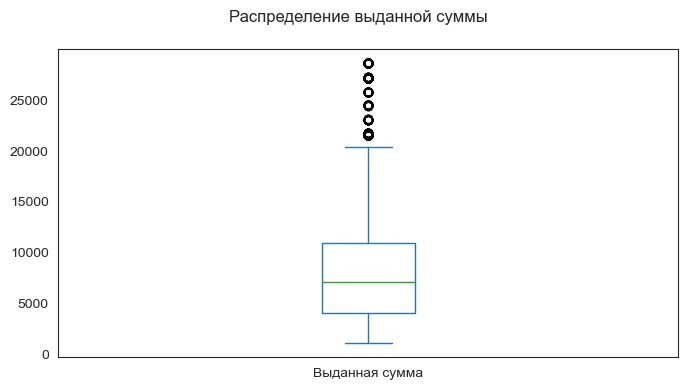

In [190]:
data = orders['issued_sum'].rename('Выданная сумма')
ax = data.plot(kind='box')
plt.suptitle('Распределение выданной суммы')

 Выбросы предыдущего графика

In [191]:
def bound(x):
    iqr = x.quantile(0.75) - x.quantile(0.25)
    return x.quantile(0.75) + 1.5 * iqr
data = orders.loc[lambda x: x['issued_sum'] > bound(x['issued_sum'])]

 Количество выбросов

In [192]:
display(data.shape[0])

505

 Выбросы начинаются с суммы выдачи

In [193]:
display(data['issued_sum'].min())

21550.0

Text(0.5, 0.98, 'Общее количество выданных заявок')

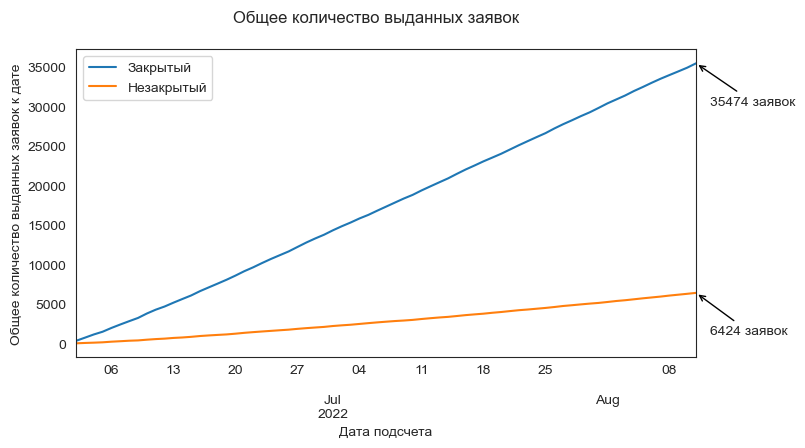

In [194]:
data = (
    orders
    .assign(
        is_closed=lambda x: ~x['closed_at'].isna(),
        put_at_norm=lambda x: x['put_at'].dt.normalize(),
    )
    .groupby([pd.Grouper(key='put_at_norm', freq='D'), 'is_closed'])
    .agg({'order_id': 'nunique'})
    .reset_index()
    .assign(
        is_closed=lambda x: x['is_closed'].map(
            {True: 'Закрытый', False: 'Незакрытый'}
        )
    )
    .pivot(index='put_at_norm', columns='is_closed', values='order_id')
    .cumsum()
)
ax = data.plot()

for _, value in data.iloc[-1].items():
    ax.annotate(
        text=f'{value} заявок',
        xy=(relevancy_date + pd.Timedelta(-1, 'd'), value),
        xycoords='data',
        xytext=(10, -30),
        textcoords='offset points',
        arrowprops={'color': 'black', 'arrowstyle': '->'},
    )

plt.ylabel('Общее количество выданных заявок к дате')
plt.xlabel('Дата подсчета')
plt.legend()
plt.suptitle('Общее количество выданных заявок')

 Исследование сроков закрытия

Text(0, 0.5, 'Количество заявок')

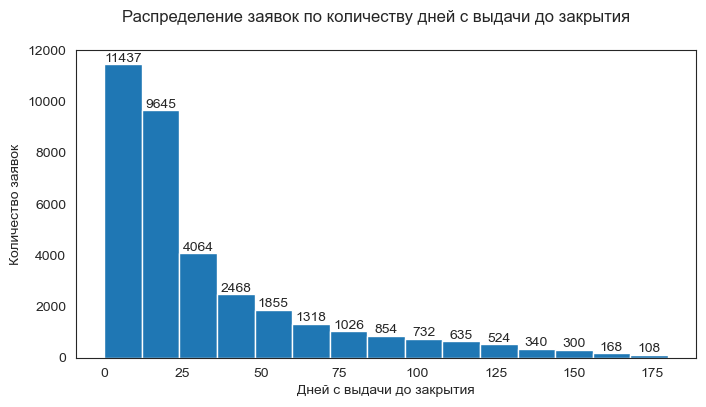

In [195]:
data = (
    orders
    .loc[lambda x: ~x['closed_at'].isna()]
    .assign(
        time_to_close=lambda x: (x['closed_at'] - x['put_at']).dt.days
    )
    ['time_to_close']
)
data[data < 0] = 0
ax = data.hist(bins=15, grid=False)
ax.bar_label(ax.containers[0])

plt.suptitle('Распределение заявок по количеству дней c выдачи до закрытия')
plt.xlabel('Дней с выдачи до закрытия')
plt.ylabel('Количество заявок')

Text(0, 0.5, 'Количество заявок')

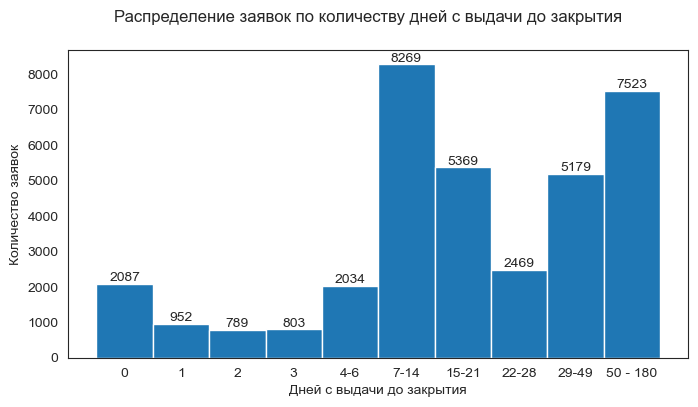

In [196]:
data = (
    orders
    .loc[lambda x: ~x['closed_at'].isna()]
    .assign(
        time_to_close=lambda x: (x['closed_at'] - x['put_at']).dt.days
    )
    ['time_to_close']
)
data[data < 0] = 0
bins = [0, 1, 2, 3, 4, 7, 15, 22, 29, 50, data.max()]
tick_labels = [f'{bins[i]}' for i in range(4)]
tick_labels.extend([f'{bins[i]}-{bins[i+1] - 1}' for i in range(4, len(bins)-1)])
tick_labels[-1] = f'{bins[-2]} - {bins[-1]}'
hist, bin_edges = np.histogram(data, bins)
fig, ax = plt.subplots()
ax.bar(
    range(len(hist)),
    hist,
    width=1,
    tick_label=tick_labels
)
ax.bar_label(ax.containers[0])

plt.suptitle('Распределение заявок по количеству дней c выдачи до закрытия')
plt.xlabel('Дней с выдачи до закрытия')
plt.ylabel('Количество заявок')

In [197]:
print(tick_labels)

['0', '1', '2', '3', '4-6', '7-14', '15-21', '22-28', '29-49', '50 - 180']


In [198]:
data.describe()

count    35474.000000
mean        31.652957
std         35.075302
min          0.000000
25%          9.000000
50%         17.000000
75%         42.000000
max        180.000000
Name: time_to_close, dtype: float64

 90ый персентиль сроков закрытия

In [199]:
data.quantile(0.90)

85.0

 ## **Заключение по разделу**

 * Можно вывести, что на пять закрытых заявок приходится одна с продолжительной задолженностью

 * Рассматриваемый период характеризуется линейным ростом заявок

 * Суммы начиная с 21550 руб являются нетипичными для выдачи

 * Половина от общего числа закрытых заявок погашаются не более чем через 17 дней после выдачи

 * Треть закрытых заявок погашается не более чем за 42 дня

 * 90% закрытых заявок погашаются не более чем за 85 дней, что соответствует приблизительно 5 плановым платежам

 * В целом прослеживается склонность к погашению не ранее чем через неделю после выдачи

 ## Подсчет итогов к каждому запланированному платежу

In [200]:
closed_orders = (
    orders
    .loc[lambda x: ~x['closed_at'].isna()]['order_id']
    .values
)

fill_strategy = dict(
    n_payments_made=0,
    paid_sum=0,
)

planned_payments = (
    plan
    .assign(
        n_plan_payment=lambda x: x.groupby('order_id')['plan_at'].transform( 'cumcount') + 1
    )
    .merge(orders, how='right', on='order_id')
    .merge(
        (
            payments.assign(
                n_payments_made=lambda x: x.groupby('order_id')['paid_at'].transform('cumcount') + 1
            )
        ),
        how='left',
        on='order_id',
    )
    .fillna(value=fill_strategy)
    # Необходимо учесть заявки по которым вообще нет платежей
    .loc[
        lambda x: (x['paid_at'].dt.date <= x['plan_at'].dt.date) | (x['paid_at'].isna())
    ]
    .assign(
        paid_to_date=lambda x: x.groupby(['order_id', 'plan_at'])[
            'paid_sum'
        ].transform('sum'),
        plan_to_paid_diff=lambda x: x['plan_sum_total'] - x['paid_to_date'],
        issued_to_paid_diff=lambda x: (x['issued_sum'] - x['paid_to_date']),
        is_closed=lambda x: x['order_id'].isin(closed_orders),
        is_overdue=lambda x: x['plan_to_paid_diff'] > 0.01,
    )
    .astype({'n_payments_made': 'int64'})
)
planned_payments

,order_id,plan_at,plan_sum_total,n_plan_payment,created_at,put_at,closed_at,issued_sum,paid_at,paid_sum,n_payments_made,paid_to_date,plan_to_paid_diff,issued_to_paid_diff,is_closed,is_overdue
0,400001732,2022-06-02,5600.0,1,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02 20:20:16.790,5600.0,1,5600.0,0.0,8000.0,True,False
7,400001732,2022-07-02,9450.0,2,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02 20:20:16.790,5600.0,1,9450.0,0.0,4150.0,True,False
8,400001732,2022-07-02,9450.0,2,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-16 16:05:26.007,3850.0,2,9450.0,0.0,4150.0,True,False
14,400001732,2022-08-01,12170.0,3,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02 20:20:16.790,5600.0,1,12170.0,0.0,1430.0,True,False
15,400001732,2022-08-01,12170.0,3,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-16 16:05:26.007,3850.0,2,12170.0,0.0,1430.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1131239,474529240,2022-11-09,1878.0,4,2022-08-11 23:48:38.000,2022-08-11 23:52:14.337,2022-09-20 00:42:22.763,1720.0,2022-09-20 00:42:22.763,2910.0,1,2910.0,-1032.0,-1190.0,True,False
1131240,474529240,2022-12-09,2222.0,5,2022-08-11 23:48:38.000,2022-08-11 23:52:14.337,2022-09-20 00:42:22.763,1720.0,2022-09-20 00:42:22.763,2910.0,1,2910.0,-688.0,-1190.0,True,False
1131241,474529240,2023-01-08,2566.0,6,2022-08-11 23:48:38.000,2022-08-11 23:52:14.337,2022-09-20 00:42:22.763,1720.0,2022-09-20 00:42:22.763,2910.0,1,2910.0,-344.0,-1190.0,True,False
1131242,474529240,2023-02-07,2910.0,7,2022-08-11 23:48:38.000,2022-08-11 23:52:14.337,2022-09-20 00:42:22.763,1720.0,2022-09-20 00:42:22.763,2910.0,1,2910.0,0.0,-1190.0,True,False


 Столбцы новой таблицы planned_payments:<br>

 **n_plan_payment** - порядковый номер планового платежа<br>

 **n_payments_made** - количество платежей до планового<br>

 **paid_to_date** - сумма платежей до планового<br>

 **plan_to_paid_diff** - разница между суммой совершенных к дате платежей и плановым. Положительная разница означает наличие задолженности<br>

 **issued_to_paid_diff** - разница выданной суммой и суммой совершенных к дате платежей. Положительное значение - банк недополучил денег, отрицательное - банк в плюсе<br>

 **is_closed** - является ли заявка закрытой<br>

 **is_overdue** - является ли плановый платеж просроченным<br>

In [201]:
# Каждому плановому платежу соответствует последний совершенный
last_payment_to_plan = (
    planned_payments
    .groupby(by=['order_id', 'plan_at'])
    .last()
    .reset_index()
)
last_payment_to_plan

,order_id,plan_at,plan_sum_total,n_plan_payment,created_at,put_at,closed_at,issued_sum,paid_at,paid_sum,n_payments_made,paid_to_date,plan_to_paid_diff,issued_to_paid_diff,is_closed,is_overdue
0,400001732,2022-06-02,5600.0,1,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-02 20:20:16.790,5600.0,1,5600.0,0.0,8000.0,True,False
1,400001732,2022-07-02,9450.0,2,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-06-16 16:05:26.007,3850.0,2,9450.0,0.0,4150.0,True,False
2,400001732,2022-08-01,12170.0,3,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-07-15 12:32:34.087,2720.0,3,12170.0,0.0,1430.0,True,False
3,400001732,2022-08-31,14890.0,4,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-08-16 12:38:01.237,2720.0,4,14890.0,0.0,-1290.0,True,False
4,400001732,2022-09-30,17610.0,5,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0,2022-09-27 16:04:50.630,2720.0,6,20330.0,-2720.0,-6730.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302166,474529240,2022-11-09,1878.0,4,2022-08-11 23:48:38.000,2022-08-11 23:52:14.337,2022-09-20 00:42:22.763,1720.0,2022-09-20 00:42:22.763,2910.0,1,2910.0,-1032.0,-1190.0,True,False
302167,474529240,2022-12-09,2222.0,5,2022-08-11 23:48:38.000,2022-08-11 23:52:14.337,2022-09-20 00:42:22.763,1720.0,2022-09-20 00:42:22.763,2910.0,1,2910.0,-688.0,-1190.0,True,False
302168,474529240,2023-01-08,2566.0,6,2022-08-11 23:48:38.000,2022-08-11 23:52:14.337,2022-09-20 00:42:22.763,1720.0,2022-09-20 00:42:22.763,2910.0,1,2910.0,-344.0,-1190.0,True,False
302169,474529240,2023-02-07,2910.0,7,2022-08-11 23:48:38.000,2022-08-11 23:52:14.337,2022-09-20 00:42:22.763,1720.0,2022-09-20 00:42:22.763,2910.0,1,2910.0,0.0,-1190.0,True,False


 ## Заявки без платежей

In [202]:
orders_with_no_payments = (
    planned_payments
    .loc[lambda x: x['paid_at'].isna()]
)
orders_with_no_payments

,order_id,plan_at,plan_sum_total,n_plan_payment,created_at,put_at,closed_at,issued_sum,paid_at,paid_sum,n_payments_made,paid_to_date,plan_to_paid_diff,issued_to_paid_diff,is_closed,is_overdue
1585,400087077,2022-06-02,920.00,1,2022-06-02 06:49:06.997,2022-06-02 06:50:21.053,NaT,2920.0,NaT,0.0,0,0.0,920.00,2920.0,False,True
1586,400087077,2022-06-17,1380.00,2,2022-06-02 06:49:06.997,2022-06-02 06:50:21.053,NaT,2920.0,NaT,0.0,0,0.0,1380.00,2920.0,False,True
1587,400087077,2022-07-02,2112.51,3,2022-06-02 06:49:06.997,2022-06-02 06:50:21.053,NaT,2920.0,NaT,0.0,0,0.0,2112.51,2920.0,False,True
1588,400087077,2022-07-17,2720.41,4,2022-06-02 06:49:06.997,2022-06-02 06:50:21.053,NaT,2920.0,NaT,0.0,0,0.0,2720.41,2920.0,False,True
1589,400087077,2022-08-01,3147.70,5,2022-06-02 06:49:06.997,2022-06-02 06:50:21.053,NaT,2920.0,NaT,0.0,0,0.0,3147.70,2920.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128462,474171752,2022-12-09,2250.90,5,2022-08-11 19:00:59.997,2022-08-11 19:03:52.240,NaT,1720.0,NaT,0.0,0,0.0,2250.90,1720.0,False,True
1128463,474171752,2023-01-08,2594.90,6,2022-08-11 19:00:59.997,2022-08-11 19:03:52.240,NaT,1720.0,NaT,0.0,0,0.0,2594.90,1720.0,False,True
1128464,474171752,2023-02-07,2938.90,7,2022-08-11 19:00:59.997,2022-08-11 19:03:52.240,NaT,1720.0,NaT,0.0,0,0.0,2938.90,1720.0,False,True
1129433,474281800,2022-08-26,6740.96,1,2022-08-11 20:15:20.000,2022-08-11 20:20:07.050,NaT,3000.0,NaT,0.0,0,0.0,6740.96,3000.0,False,True


 Количество заявок без платежей

In [203]:
len(orders_with_no_payments['order_id'].unique())

1478

 Доля заявок без платежей от общего количества

In [204]:
len(orders_with_no_payments['order_id'].unique()) / len(orders)

0.035276146832784384

 Выданная сумма на заявках без платежей

Text(0, 0.5, 'Выданная сумма')

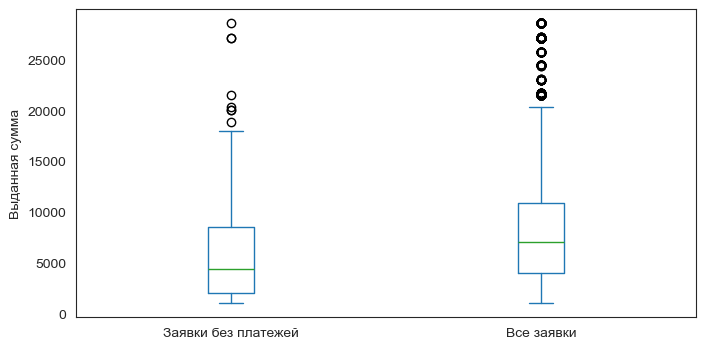

In [205]:
data = (
    orders_with_no_payments
    .groupby(by='order_id')
    .agg('first')['issued_sum']
)
data2 = orders['issued_sum']
ax = pd.DataFrame({'Заявки без платежей': data, 'Все заявки': data2}).plot(
    kind='box'
)
plt.ylabel('Выданная сумма')

 ## Заявки погашенные одним платежом

 Среди записей о заявках особенно выделяется группа, характеризуемая погашением единственной оплатой. Стоит дать характиристку этой группе с целью формирования стратегии по обращению с такими заявками, а именно: является ли такое поведение допустимым для банка и возможно ли его поощрять.

In [206]:
one_payment_and_in_advance = (
    last_payment_to_plan
    .groupby('order_id')
    .last()
    .loc[
        lambda x: (x['n_plan_payment'] == 1)
        & (x['issued_to_paid_diff'] < 0)
        & (x['is_closed'])
    ]
)
one_payment_and_in_advance

,plan_at,plan_sum_total,n_plan_payment,created_at,put_at,closed_at,issued_sum,paid_at,paid_sum,n_payments_made,paid_to_date,plan_to_paid_diff,issued_to_paid_diff,is_closed,is_overdue
order_id,,,,,,,,,,,,,,,
400005838,2022-06-17,23000.0,1,2022-06-02 00:10:22.997,2022-06-02 15:41:33.267,2022-06-02 17:38:43.917,20000.0,2022-06-02 17:38:43.917,20200.0,1,20200.0,2800.0,-200.0,True,True
400014289,2022-06-17,11500.0,1,2022-06-02 01:12:32.000,2022-06-02 01:14:07.683,2022-06-06 15:04:37.347,10000.0,2022-06-06 15:04:37.347,10400.0,1,10400.0,1100.0,-400.0,True,True
400014464,2022-06-17,3450.0,1,2022-06-02 01:17:28.000,2022-06-02 01:22:27.323,2022-06-06 16:29:00.720,3000.0,2022-06-06 16:29:00.720,3120.0,1,3120.0,330.0,-120.0,True,True
400015650,2022-06-17,2300.0,1,2022-06-02 01:21:03.997,2022-06-02 01:22:39.567,2022-06-02 18:24:34.800,2000.0,2022-06-02 18:24:34.800,2020.0,1,2020.0,280.0,-20.0,True,True
400017748,2022-06-17,10350.0,1,2022-06-02 01:38:27.997,2022-06-02 01:43:41.537,2022-06-09 05:47:45.863,9000.0,2022-06-09 05:47:45.863,9630.0,1,9630.0,720.0,-630.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474501978,2022-08-26,4600.0,1,2022-08-11 23:14:56.997,2022-08-11 23:16:31.447,2022-08-13 22:50:48.907,4000.0,2022-08-13 22:50:48.907,4080.0,1,4080.0,520.0,-80.0,True,True
474504430,2022-08-26,5750.0,1,2022-08-11 23:35:29.000,2022-08-11 23:36:33.447,2022-08-12 00:41:25.263,5000.0,2022-08-12 00:41:25.263,5050.0,1,5050.0,700.0,-50.0,True,True
474509201,2022-08-26,11500.0,1,2022-08-11 23:35:30.000,2022-08-11 23:40:52.050,2022-08-24 21:23:14.147,10000.0,2022-08-24 21:23:14.147,11300.0,1,11300.0,200.0,-1300.0,True,True


Text(0, 0.5, 'Количество заявок')

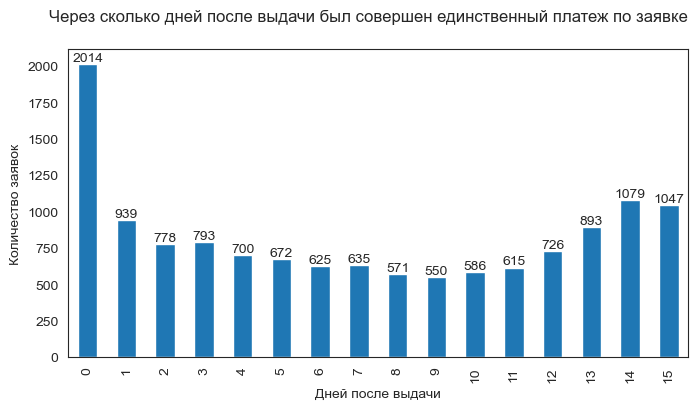

In [207]:
data = (
    one_payment_and_in_advance
    .assign(time_to_close=lambda x: (x['closed_at'] - x['put_at']).dt.days)
    ['time_to_close']
    .value_counts()
    .sort_index()
)
ax = data.plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.suptitle('Через сколько дней после выдачи был совершен единственный платеж по заявке')
plt.xlabel('Дней после выдачи')
plt.ylabel('Количество заявок')

 Количество заявок погашенных одним платежом

In [208]:
len(one_payment_and_in_advance)

13223

 Доля заявок погашенных одним платежом среди всех

In [209]:
len(one_payment_and_in_advance) / len(orders)

0.31559978996610816

In [210]:
one_payment_and_in_advance_pct_values = (
    one_payment_and_in_advance
    .assign(
        pct_isp_diff=lambda x: np.abs(x['issued_to_paid_diff']) / x['issued_sum'],
        pct_ptp_diff=lambda x: round( np.abs(x['paid_sum']) / x['plan_sum_total'], ndigits=3),
    )
    .loc[:, ['pct_isp_diff', 'pct_ptp_diff']] 
)
one_payment_and_in_advance_pct_values

,pct_isp_diff,pct_ptp_diff
order_id,,
400005838,0.01,0.878
400014289,0.04,0.904
400014464,0.04,0.904
400015650,0.01,0.878
400017748,0.07,0.930
...,...,...
474501978,0.02,0.887
474504430,0.01,0.878
474509201,0.13,0.983


In [211]:
rus_names = {
    'pct_isp_diff': 'Прибыль от выданной суммы',
    'pct_ptp_diff': 'Доля от планового платежа',
}

Text(0.5, 0.98, 'Специфика заявок погашенных досрочно одним платежом')

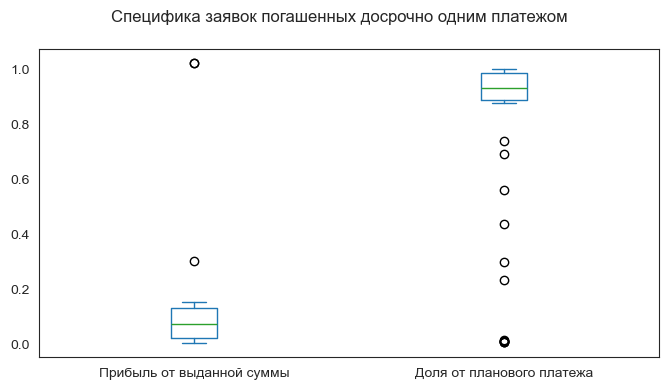

In [212]:
data = (
    one_payment_and_in_advance_pct_values
    .rename(columns=rus_names)
)
ax = data.plot(kind='box')
plt.suptitle('Специфика заявок погашенных досрочно одним платежом')

 Выбросы boxplot

In [213]:
# ??? Либо метки в данных, либо как-то неправильно оформленные заявки
(
    one_payment_and_in_advance_pct_values
    .loc[lambda x: (x['pct_isp_diff'] > 0.2) | (x['pct_ptp_diff'] < 0.8)]
)

,pct_isp_diff,pct_ptp_diff
order_id,,
401467534,0.030000,0.435
411504997,1.020000,0.878
412345004,0.000650,0.005
422632789,1.020000,0.878
427522653,0.068571,0.557
428786056,0.000700,0.005
432586862,0.022505,0.011
432873626,0.150000,0.009
441882460,0.150000,0.009


Text(0, 0.5, 'Количество заявок')

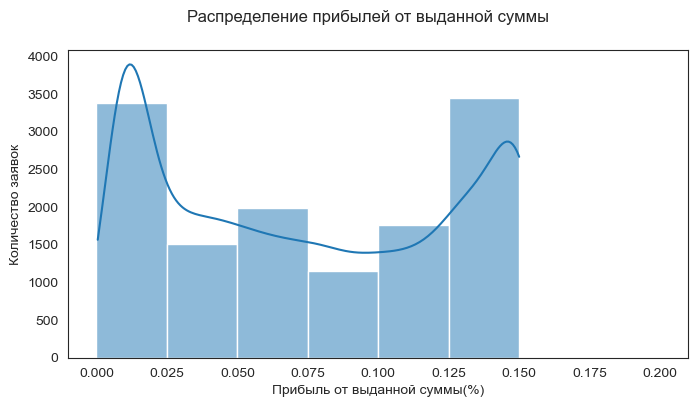

In [214]:
data = (
    one_payment_and_in_advance_pct_values
    .loc[lambda x: x['pct_isp_diff'] < 0.2]
    .rename(columns=rus_names)
    .iloc[:, 0]
)
sns.histplot(data, kde=True, binrange=(0, 0.2), bins=8)
plt.suptitle('Распределение прибылей от выданной суммы')
plt.xlabel('Прибыль от выданной суммы(%)')
plt.ylabel('Количество заявок')

Text(0, 0.5, 'Количество заявок')

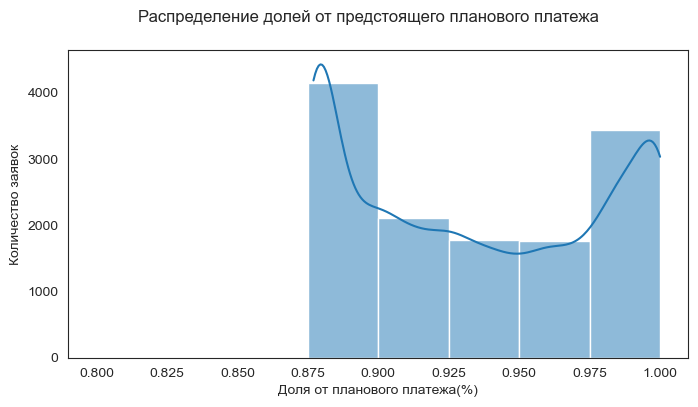

In [215]:
data = (
    one_payment_and_in_advance_pct_values
    .loc[lambda x: x['pct_ptp_diff'] > 0.8]
    .rename(columns=rus_names)
    .iloc[:, 1]
)
sns.histplot(data, kde=True, binrange=(0.8, 1), bins=8)
plt.suptitle('Распределение долей от предстоящего планового платежа')
plt.xlabel('Доля от планового платежа(%)')
plt.ylabel('Количество заявок')

 Среднее гармоническое

In [216]:
(
    one_payment_and_in_advance_pct_values
    .rename(columns=rus_names)
    .agg(hmean)
)

Прибыль от выданной суммы    0.030556
Доля от планового платежа    0.869866
dtype: float64

 Среднее арифметическое. Выбросы исключены.

In [217]:
(
    one_payment_and_in_advance_pct_values
    .loc[lambda x: (x['pct_isp_diff'] < 0.2) | (x['pct_ptp_diff'] > 0.8)]
    .rename(columns=rus_names)
    .agg('mean')
)

Прибыль от выданной суммы    0.075275
Доля от планового платежа    0.934224
dtype: float64

In [218]:
(
    one_payment_and_in_advance_pct_values
    .rename(columns=rus_names)
    .describe()
)

,Прибыль от выданной суммы,Доля от планового платежа
count,13223.000000,13223.000000
mean,0.075292,0.934171
std,0.052440,0.050389
min,0.000450,0.005000
25%,0.020000,0.887000
50%,0.070000,0.930000
75%,0.130000,0.983000
max,1.020000,1.000000


 ## **Заключение по разделу**

 * Заявки погашенные одним досрочным платежом составляют 32 процента от всех оформленных заявок, что является значительной долей.

 * Абсолютное большинство выделенных заявок прибыльные не более чем 15% от суммы выдачи, и выплачиваются на сумму не менее чем 85% от запланированной к первому платежу.

 * Несмотря на совпадающие медиану и среднее, распределения не являются нормальными

 ## Исследование незакрытых заявок

In [219]:
unclosed_overdue_last_payment = (
    last_payment_to_plan
    .loc[lambda x: x['is_overdue'] & ~x['is_closed']]
    .sort_values(['order_id', 'plan_at'])
    .groupby('order_id')
    .last()
)
unclosed_overdue_last_payment

,plan_at,plan_sum_total,n_plan_payment,created_at,put_at,closed_at,issued_sum,paid_at,paid_sum,n_payments_made,paid_to_date,plan_to_paid_diff,issued_to_paid_diff,is_closed,is_overdue
order_id,,,,,,,,,,,,,,,
400039450,2022-11-21,15917.51,13,2022-06-02 06:06:20.000,2022-06-02 17:04:46.147,NaT,8140.0,2022-06-02 17:06:09.907,2140.00,1,2140.00,13777.51,6000.00,False,True
400087077,2022-11-29,5675.95,13,2022-06-02 06:49:06.997,2022-06-02 06:50:21.053,NaT,2920.0,NaT,0.00,0,0.00,5675.95,2920.00,False,True
400104071,2022-11-29,3025.25,7,2022-06-02 07:24:24.000,2022-06-02 07:40:44.230,NaT,1720.0,NaT,0.00,0,0.00,3025.25,1720.00,False,True
400114009,2022-11-29,23961.20,7,2022-06-02 07:46:38.000,2022-06-02 07:54:54.360,NaT,13600.0,2022-07-17 12:26:54.400,3850.00,2,9450.00,14511.20,4150.00,False,True
400128637,2022-11-29,14979.50,7,2022-06-02 08:37:15.000,2022-06-02 08:56:56.887,NaT,8500.0,NaT,0.00,0,0.00,14979.50,8500.00,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474459935,2023-02-07,19813.15,13,2022-08-11 22:26:34.000,2022-08-11 23:19:21.343,NaT,11680.0,2022-12-08 11:09:11.533,1141.44,8,15406.57,4406.58,-3726.57,False,True
474492382,2023-02-07,25543.75,13,2022-08-11 22:43:57.997,2022-08-11 22:46:06.820,NaT,14600.0,2022-09-09 17:30:21.080,1822.27,3,9322.27,16221.48,5277.73,False,True
474512409,2023-02-07,31890.66,13,2022-08-11 23:37:31.000,2022-08-11 23:40:09.540,NaT,18850.0,2022-11-27 11:45:26.817,500.00,11,22436.09,9454.57,-3586.09,False,True


Text(0.5, 0.98, 'Номер последнего запланированного платежа на незакрытых заявках')

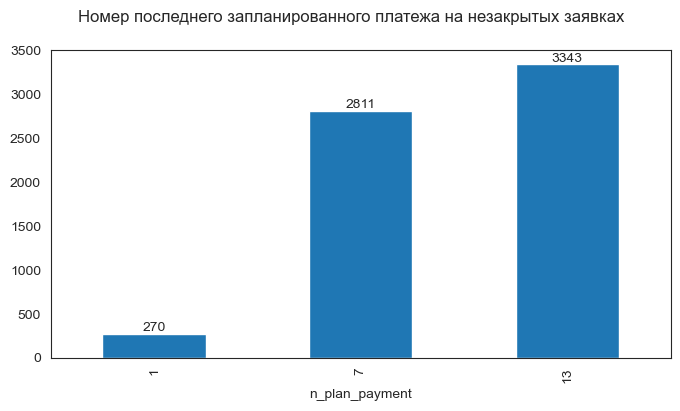

In [220]:
ax = (
    unclosed_overdue_last_payment
    ['n_plan_payment']
    .value_counts()
    .sort_index()
    .plot(kind='bar')
)
ax.bar_label(ax.containers[0])
plt.suptitle('Номер последнего запланированного платежа на незакрытых заявках')

 Выбросы предыдущего графика

In [221]:
(
    unclosed_overdue_last_payment
    .loc[lambda x: x['n_plan_payment'].isin([14, 16, 25])]
)

,plan_at,plan_sum_total,n_plan_payment,created_at,put_at,closed_at,issued_sum,paid_at,paid_sum,n_payments_made,paid_to_date,plan_to_paid_diff,issued_to_paid_diff,is_closed,is_overdue
order_id,,,,,,,,,,,,,,,


Text(0.5, 0.98, 'Количество платежей на незакрытых заявках')

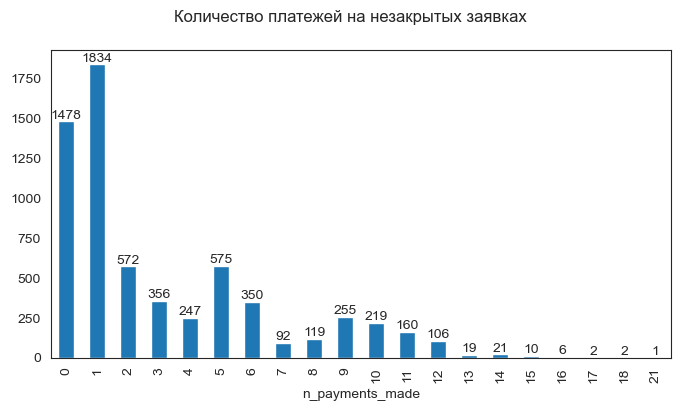

In [222]:
ax = (
    unclosed_overdue_last_payment
    ['n_payments_made']
    .value_counts()
    .sort_index()
    .plot(kind='bar')
)
ax.bar_label(ax.containers[0])
plt.suptitle('Количество платежей на незакрытых заявках')

Text(0.5, 0.98, 'Доля выплаченной суммы от выданной')

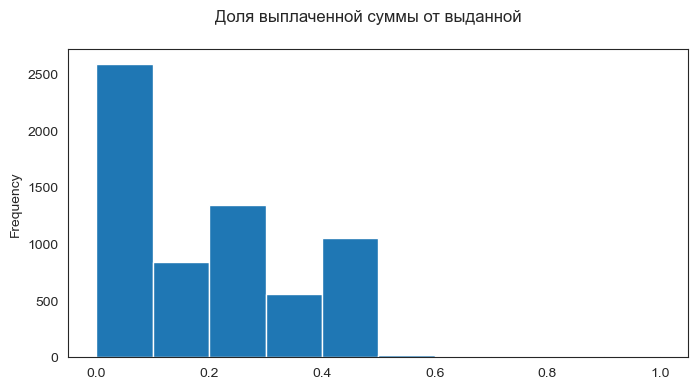

In [223]:
data = (
    unclosed_overdue_last_payment
    .assign(
        pct_of_issued=lambda x: x['paid_sum'] / x['issued_sum']
    )
    ['pct_of_issued']
)
ax = data.plot(kind='hist', bins=np.arange(0, 1.1, 0.1))
plt.suptitle('Доля выплаченной суммы от выданной')

 Сумма невыплаченных средств на незакрытых заявках к последнему запланированному платежу

In [224]:
rus_names = {
    'issued_to_paid_diff': 'Сумма невыплаченных средств',
    'plan_to_paid_diff': 'Сумма невыплаченных средств с учетом процентов',
}

(
    unclosed_overdue_last_payment.agg(
        {'issued_to_paid_diff': 'sum', 'plan_to_paid_diff': 'sum'}
    ).rename(rus_names)
)

Сумма невыплаченных средств                       13631763.57
Сумма невыплаченных средств с учетом процентов    50971592.51
dtype: float64

 ## **Заключения по разделу**

 * Незакрытые заявки распланированы не более чем на 13 периодов

 * На незакрытых заявках было потеряно 14 млн

 * Незакрытые заявки выплачиваются не более чем на половину от выданной суммы

 ## Просроченные платежи

In [225]:
# Открытые заявки и заявки погашенные заранее одним платежом рассмотрены в отдельных разделах
overdue_payments = (
    planned_payments
    .loc[
        lambda x: x['is_closed'] &
         x['is_overdue'] &
         ~x['order_id'].isin(one_payment_and_in_advance.index.values)
    ]
    # Оставим только уникальные плановые платежи
    .groupby(['order_id', 'plan_at'])
    .last()
    .reset_index()
)
overdue_payments

,order_id,plan_at,plan_sum_total,n_plan_payment,created_at,put_at,closed_at,issued_sum,paid_at,paid_sum,n_payments_made,paid_to_date,plan_to_paid_diff,issued_to_paid_diff,is_closed,is_overdue
0,400007915,2022-06-20,2730.00,2,2022-06-02 00:18:04.000,2022-06-05 19:17:38.547,2022-06-21 21:55:51.877,5820.0,2022-06-05 19:18:12.457,1820.00,1,1820.00,910.00,4000.00,True,True
1,400010534,2022-07-02,9417.67,3,2022-06-02 00:46:35.000,2022-06-02 11:42:04.560,2022-07-14 22:15:19.217,14600.0,2022-06-17 19:17:38.240,2300.00,2,6900.00,2517.67,7700.00,True,True
2,400013633,2022-06-09,3750.00,2,2022-06-02 00:46:38.000,2022-06-02 00:47:46.277,2022-06-16 03:15:48.960,9500.0,2022-06-02 00:48:13.800,2500.00,1,2500.00,1250.00,7000.00,True,True
3,400017255,2022-07-09,4000.98,4,2022-06-02 01:35:50.997,2022-06-02 22:25:52.367,2022-07-10 23:41:17.397,5430.0,2022-06-22 22:31:56.903,1063.77,3,3208.77,792.21,2221.23,True,True
4,400020168,2022-07-17,10415.85,4,2022-06-02 02:19:32.000,2022-06-02 03:13:16.420,2022-10-31 14:15:23.383,13200.0,2022-07-02 09:29:51.897,2190.00,3,8490.00,1925.85,4710.00,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20008,474436552,2022-08-26,2730.00,2,2022-08-11 21:55:36.000,2022-08-11 21:57:34.213,2022-10-17 09:50:34.507,5820.0,2022-08-11 21:59:18.493,1820.00,1,1820.00,910.00,4000.00,True,True
20009,474436552,2022-09-10,3812.51,3,2022-08-11 21:55:36.000,2022-08-11 21:57:34.213,2022-10-17 09:50:34.507,5820.0,2022-08-11 21:59:18.493,1820.00,1,1820.00,1992.51,4000.00,True,True
20010,474436552,2022-09-25,4715.59,4,2022-08-11 21:55:36.000,2022-08-11 21:57:34.213,2022-10-17 09:50:34.507,5820.0,2022-08-11 21:59:18.493,1820.00,1,1820.00,2895.59,4000.00,True,True
20011,474436552,2022-10-10,5397.40,5,2022-08-11 21:55:36.000,2022-08-11 21:57:34.213,2022-10-17 09:50:34.507,5820.0,2022-08-11 21:59:18.493,1820.00,1,1820.00,3577.40,4000.00,True,True


 Количество просроченных плановых платежей

In [226]:
overdue_payments.shape[0]

20013

 Доля просроченных плановых платежей от всех запланированных

In [227]:
round(overdue_payments.shape[0] / plan.shape[0], 4)

0.0476

Text(0.02, 0.5, 'Количество просроченных платежей')

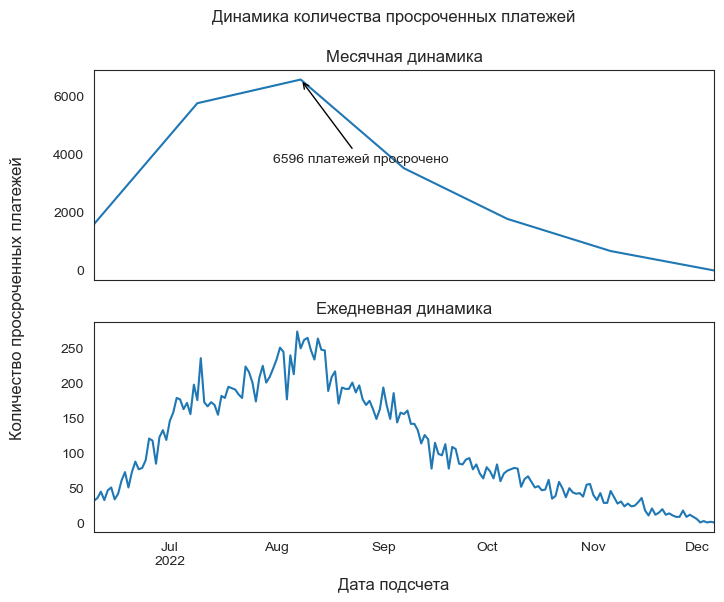

In [228]:
data_monthly = (
    overdue_payments
    .groupby([pd.Grouper(key='plan_at', freq='ME')])
    .agg({'order_id': 'count'})
)
data_daily = (
    overdue_payments
    .groupby([pd.Grouper(key='plan_at', freq='D')])
    .agg({'order_id': 'count'})
)
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
data_monthly.plot(ax=axes[0], sharex=True)
data_daily.plot(ax=axes[1], sharex=True)
axes[0].set_title('Месячная динамика')
data_monthly.reset_index()
xmax, ymax = data_monthly.idxmax().values[0], data_monthly.max().values[0], 
axes[0].annotate(
    text=f'{ymax} платежей просрочено',
    xy=(xmax, ymax),
    xycoords='data',
    xytext=(-20, -60),
    textcoords='offset points',
    arrowprops={'color': 'black', 'arrowstyle': '->'}
)
axes[1].set_title('Ежедневная динамика')
axes[1].set_xlabel('')
for ax in axes:
    ax.legend().set_visible(False)
fig.suptitle('Динамика количества просроченных платежей')
fig.supxlabel('Дата подсчета')
fig.supylabel('Количество просроченных платежей')

Text(0, 0.5, 'Количество просроченых платежей')

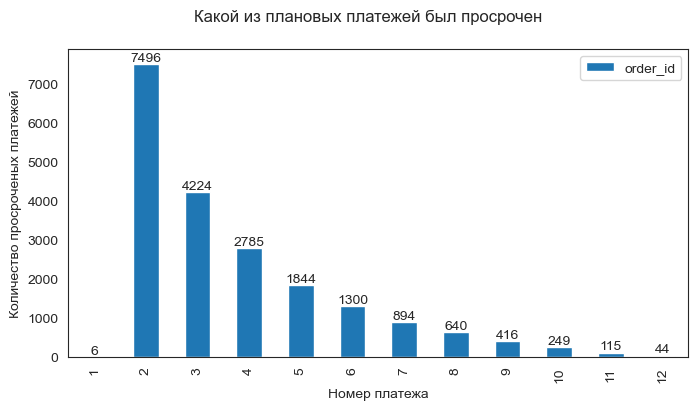

In [229]:
data = (
    overdue_payments
    .groupby(by='n_plan_payment')
    .agg({'order_id': 'nunique'})
)
ax = data.plot(kind='bar')
ax.bar_label(ax.containers[0])

plt.suptitle('Какой из плановых платежей был просрочен')
plt.xlabel('Номер платежа')
plt.ylabel('Количество просроченых платежей')

Text(0.5, 0, 'Платежи с задолженностью')

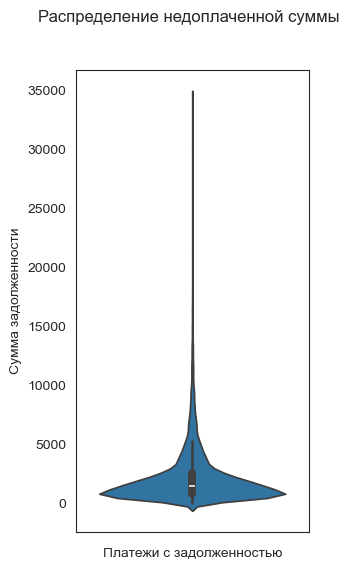

In [230]:
data = overdue_payments['plan_to_paid_diff']
fig, ax = plt.subplots(figsize=(3,6))
sns.violinplot(data, ax=ax)
plt.suptitle('Распределение недоплаченной суммы')
plt.ylabel('Сумма задолженности')
plt.xlabel('Платежи с задолженностью')

 Статистики суммы задолженности

In [231]:
data.describe()

count    20013.000000
mean      2188.121165
std       2365.487944
min          0.050000
25%        774.280000
50%       1425.000000
75%       2576.240000
max      34306.910000
Name: plan_to_paid_diff, dtype: float64

 90ый персентиль

In [232]:
data.quantile(0.90)

4798.1900000000005

Text(0.5, 0, 'Платежи с задолженностью')

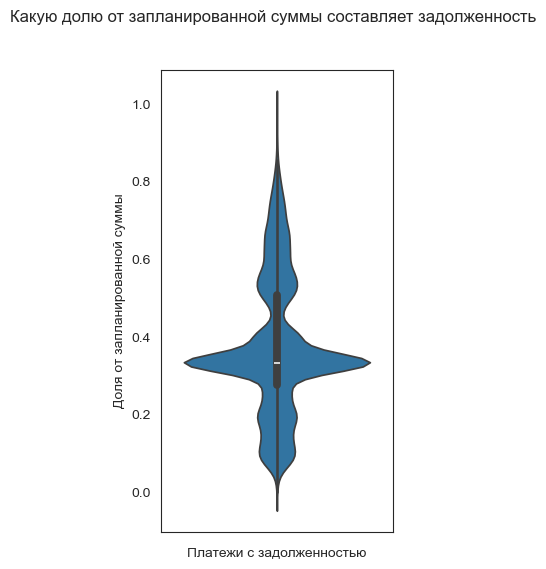

In [233]:
data = (
    overdue_payments
    .assign(
        pct_of_plan=lambda x: x['plan_to_paid_diff'] / x['plan_sum_total']
    )
    ['pct_of_plan']
)
fig, ax = plt.subplots(figsize=(3,6))
sns.violinplot(data, ax=ax)
plt.suptitle('Какую долю от запланированной суммы составляет задолженность')
plt.ylabel('Доля от запланированной суммы')
plt.xlabel('Платежи с задолженностью')

 Статистики доли от запланированной суммы

In [234]:
data.describe()

count    20013.000000
mean         0.375014
std          0.175705
min          0.000007
25%          0.275983
50%          0.333333
75%          0.508232
max          0.986103
Name: pct_of_plan, dtype: float64

 90ый персентиль

In [235]:
data.quantile(0.90)

0.6447552529612995

 ## **Заключения по разделу**

 * Просроченные платежи составляют около 5 процентов от всех запланированных

 * Больше всего запланированных платежей было просрочено в августе. Итог составил 6596 платежей

 * Сумма задолженности половины запланированных платежей не превышает 1500 руб, а 90% - 4800 руб

 * В долях от запланированной суммы указанные цифры составляют 33, и 64 процента соответственно

 * Есть явная тенденция к неуплате примерно трети от запланированной суммы